<a href="https://colab.research.google.com/github/medika04/tht-telco-churn/blob/main/telcochurn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd

# List the CSV files in the workspace
files = [f for f in os.listdir('.') if f.endswith('.csv')]
print("Files:", files)

# Inspect columns of each file
for file in files:
    df = pd.read_csv(file)
    print(f"\n--- {file} ---")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print(df.head(2))

Files: ['Payment_Info.csv', 'Customer_Info.csv', 'Status_Analysis.csv', 'Service_Options.csv', 'Location_Data.csv', 'Online_Services.csv']

--- Payment_Info.csv ---
Shape: (7043, 11)
Columns: ['customer_id', 'contract', 'paperless_billing', 'payment_method', 'monthly_ charges', 'avg_monthly_long_distance_charges', 'total_charges', 'total_refunds', 'total_extra_data_charges', 'total_long_distance_charges', 'total_revenue']
  customer_id        contract paperless_billing payment_method  \
0  0002-ORFBO        One Year               Yes   Mailed check   
1  0003-MKNFE  Month-to-Month                No   Mailed check   

   monthly_ charges  avg_monthly_long_distance_charges  total_charges  \
0              65.6                              42.39          593.3   
1              59.9                              10.69          542.4   

   total_refunds  total_extra_data_charges  total_long_distance_charges  \
0           0.00                         0                       381.51   
1    

In [ ]:
import pandas as pd
import numpy as np

# Load datasets
customer_info = pd.read_csv('Customer_Info.csv')
location_data = pd.read_csv('Location_Data.csv')
online_services = pd.read_csv('Online_Services.csv')
payment_info = pd.read_csv('Payment_Info.csv')
service_options = pd.read_csv('Service_Options.csv')
status_analysis = pd.read_csv('Status_Analysis.csv')

# Check column overlap to avoid duplicate columns during merge
print("Online services columns:", online_services.columns.tolist())
print("Service options columns:", service_options.columns.tolist())

# Drop overlapping columns from online_services except customer_id
online_services_sub = online_services.drop(columns=['phone_service', 'internet_service'])

# Merge all tables on customer_id
df_merged = customer_info.merge(location_data, on='customer_id', how='inner')
df_merged = df_merged.merge(service_options, on='customer_id', how='inner')
df_merged = df_merged.merge(online_services_sub, on='customer_id', how='inner')
df_merged = df_merged.merge(payment_info, on='customer_id', how='inner')
df_merged = df_merged.merge(status_analysis, on='customer_id', how='inner')

print("Merged shape:", df_merged.shape)
print("Missing values per column:\n", df_merged.isnull().sum()[df_merged.isnull().sum() > 0])

Online services columns: ['customer_id', 'phone_service', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 'internet_type']
Service options columns: ['customer_id', 'tenure', 'internet_service', 'phone_service', 'multiple_lines', 'avg_monthly_gb_download', 'unlimited_data', 'offer', 'referred_a_friend', 'number_of_referrals']
Merged shape: (7043, 51)
Missing values per column:
 offer            3877
internet_type    1526
churn_reason     5174
dtype: int64


In [ ]:
print(df_merged.columns.tolist())

# Clean column names (strip whitespace in 'monthly_ charges')
df_merged = df_merged.rename(columns={str(col): col.strip() for col in df_merged.columns})

# Fill missing values appropriately:
# - offer: 'None' or 'No Offer'
# - internet_type: 'No Internet'
# - churn_reason: 'Not Applicable' or 'None'
df_merged['offer'] = df_merged['offer'].fillna('None')
df_merged['internet_type'] = df_merged['internet_type'].fillna('None')
df_merged['churn_reason'] = df_merged['churn_reason'].fillna('None')

# Check data types and convert object columns or numerical columns if needed
print(df_merged.info())

['customer_id', 'gender', 'age', 'under_30', 'senior_citizen', 'partner', 'dependents', 'number_of_dependents', 'married', 'country', 'state', 'city', 'zip_code', 'total_population', 'latitude', 'longitude', 'tenure', 'internet_service', 'phone_service', 'multiple_lines', 'avg_monthly_gb_download', 'unlimited_data', 'offer', 'referred_a_friend', 'number_of_referrals', 'online_security', 'online_backup', 'device_protection', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 'internet_type', 'contract', 'paperless_billing', 'payment_method', 'monthly_ charges', 'avg_monthly_long_distance_charges', 'total_charges', 'total_refunds', 'total_extra_data_charges', 'total_long_distance_charges', 'total_revenue', 'satisfaction_score', 'cltv', 'customer_status', 'churn_score', 'churn_label', 'churn_value', 'churn_category', 'churn_reason']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 51 columns):
 #   Column            

In [ ]:
print("Overall Churn Rate:", df_merged['churn_value'].mean() * 100)

# Check churn by contract
print("\n--- Churn by Contract ---")
print(df_merged.groupby('contract')['churn_value'].agg(['count', 'mean']))

# Check churn by internet_type
print("\n--- Churn by Internet Type ---")
print(df_merged.groupby('internet_type')['churn_value'].agg(['count', 'mean']))

# Check churn by payment_method
print("\n--- Churn by Payment Method ---")
print(df_merged.groupby('payment_method')['churn_value'].agg(['count', 'mean']))

# Check churn by offer
print("\n--- Churn by Offer ---")
print(df_merged.groupby('offer')['churn_value'].agg(['count', 'mean']))

# Check numerical correlations with churn_value
numerical_cols = df_merged.select_dtypes(include=['int64', 'float64']).columns
corrs = df_merged[numerical_cols].corr()['churn_value'].sort_values(ascending=False)
print("\n--- Numerical Correlations with Churn Value ---")
print(corrs)

Overall Churn Rate: 26.536987079369588

--- Churn by Contract ---
                count      mean
contract                       
Month-to-Month   3610  0.458449
One Year         1550  0.107097
Two Year         1883  0.025491

--- Churn by Internet Type ---
               count      mean
internet_type                 
Cable            830  0.256627
DSL             1652  0.185835
Fiber Optic     3035  0.407249
None            1526  0.074050

--- Churn by Payment Method ---
                           count      mean
payment_method                            
Bank transfer (automatic)   1544  0.167098
Credit card (automatic)     1522  0.152431
Electronic check            2365  0.452854
Mailed check                1612  0.191067

--- Churn by Offer ---
         count      mean
offer                   
None      3877  0.271086
Offer A    520  0.067308
Offer B    824  0.122573
Offer C    415  0.228916
Offer D    602  0.267442
Offer E    805  0.529193

--- Numerical Correlations with Churn Va

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Select features for modeling
df_model = df_merged.drop(columns=['customer_id', 'country', 'state', 'city', 'zip_code', 'customer_status', 'churn_label', 'churn_category', 'churn_reason', 'churn_score'])

# Encode categorical variables
cat_cols = df_model.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model.drop(columns=['churn_value'])
y = df_model['churn_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 15 Feature Importances for Churn Prediction:")
print(importances.head(15))

Top 15 Feature Importances for Churn Prediction:
satisfaction_score                   0.481230
contract                             0.081519
tenure                               0.042558
monthly_ charges                     0.032867
number_of_referrals                  0.029633
total_revenue                        0.029081
total_charges                        0.024510
age                                  0.023605
total_long_distance_charges          0.022606
avg_monthly_gb_download              0.018493
latitude                             0.018364
total_population                     0.017360
longitude                            0.017170
cltv                                 0.016635
avg_monthly_long_distance_charges    0.014933
dtype: float64


In [ ]:
output_filename = "telco_churn_cleaned_master.csv"
df_merged.to_csv(output_filename, index=False)

from google.colab import files
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np


customer_info = pd.read_csv('Customer_Info.csv')
location_data = pd.read_csv('Location_Data.csv')
online_services = pd.read_csv('Online_Services.csv')
payment_info = pd.read_csv('Payment_Info.csv')
service_options = pd.read_csv('Service_Options.csv')
status_analysis = pd.read_csv('Status_Analysis.csv')

online_services_sub = online_services.drop(columns=['phone_service', 'internet_service'])

df_merged = customer_info.merge(location_data, on='customer_id', how='inner')
df_merged = df_merged.merge(service_options, on='customer_id', how='inner')
df_merged = df_merged.merge(online_services_sub, on='customer_id', how='inner')
df_merged = df_merged.merge(payment_info, on='customer_id', how='inner')
df_merged = df_merged.merge(status_analysis, on='customer_id', how='inner')

df_merged = df_merged.rename(columns={str(col): col.strip() for col in df_merged.columns})


service_cols = ['online_security', 'online_backup', 'device_protection', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music']
existing_service_cols = [col for col in service_cols if col in df_merged.columns]


df_merged['frequency_score'] = df_merged[existing_service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)


df_merged['monetary_value'] = df_merged['total_revenue']


df_merged['R'] = pd.qcut(df_merged['tenure'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
df_merged['F'] = pd.qcut(df_merged['frequency_score'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
df_merged['M'] = pd.qcut(df_merged['monetary_value'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)


df_merged['RFM_Score'] = df_merged['R'].astype(str) + df_merged['F'].astype(str) + df_merged['M'].astype(str)


def segment_customer(row):
    if row['M'] >= 3 and row['R'] >= 3:
        return 'Champions / VIP'
    elif row['R'] <= 2 and row['M'] >= 3:
        return 'At-Risk High Value'
    elif row['R'] >= 3 and row['M'] <= 2:
        return 'Recent / Low-Spend'
    else:
        return 'Hibernating / Lost'

df_merged['Customer_Segment'] = df_merged.apply(segment_customer, axis=1)


print("Distribusi Segmen Pelanggan RFM:")
print(df_merged['Customer_Segment'].value_counts())

output_filename = "telco_churn_with_rfm.csv"
df_merged.to_csv(output_filename, index=False)
print(f"\nFile berhasil disimpan sebagai '{output_filename}' dan siap digunakan di Power BI!")



Distribusi Segmen Pelanggan RFM:
Customer_Segment
Hibernating / Lost    3118
Champions / VIP       3117
Recent / Low-Spend     404
At-Risk High Value     404
Name: count, dtype: int64

File berhasil disimpan sebagai 'telco_churn_with_rfm.csv' dan siap digunakan di Power BI!


In [ ]:
import pandas as pd

# Filter hanya pelanggan yang benar-benar churn (churn_value == 1 atau customer_status == 'Churned')
df_churned = df_merged[df_merged['churn_value'] == 1]

# Hitung frekuensi alasan churn
churn_reasons_count = df_churned['churn_reason'].value_counts().head(10)
print("Top 10 Alasan Pelanggan Churn:")
print(churn_reasons_count)

Top 10 Alasan Pelanggan Churn:
churn_reason
Competitor had better devices                313
Competitor made better offer                 311
Attitude of support person                   220
Don't know                                   130
Competitor offered more data                 117
Competitor offered higher download speeds    100
Attitude of service provider                  94
Price too high                                78
Product dissatisfaction                       77
Network reliability                           72
Name: count, dtype: int64


Top 15 Feature Importances for Churn Prediction:
satisfaction_score             0.453392
contract                       0.055982
monthly_ charges               0.038012
number_of_referrals            0.029065
tenure                         0.028220
monetary_value                 0.025216
total_revenue                  0.022217
total_long_distance_charges    0.021550
RFM_Score                      0.021360
avg_monthly_gb_download        0.020695
total_charges                  0.020059
age                            0.019658
R                              0.018957
latitude                       0.018178
cltv                           0.017805
dtype: float64


/tmp/ipykernel_6754/1617938963.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(15).values, y=importances.head(15).index, palette='viridis')


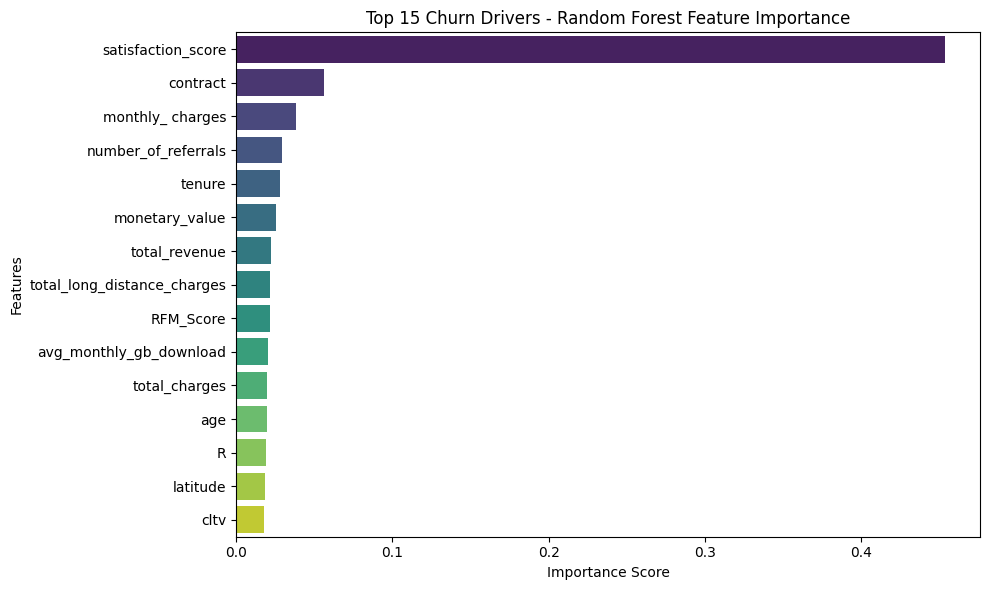

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare your dataset (Assuming df_merged is ready)
# Drop non-predictive ID columns or descriptive text columns that aren't features
drop_cols = ['customer_id', 'country', 'state', 'city', 'zip_code',
             'customer_status', 'churn_label', 'churn_category', 'churn_reason', 'churn_score']
df_model = df_merged.drop(columns=[col for col in drop_cols if col in df_merged.columns])

# 2. Encode categorical variables into numeric values so the model can read them
cat_cols = df_model.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# 3. Define Features (X) and Target (y)
X = df_model.drop(columns=['churn_value'])
y = df_model['churn_value']

# 4. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Initialize and train the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 6. Extract and sort Feature Importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 15 Feature Importances for Churn Prediction:")
print(importances.head(15))

# 7. Visualize the Top 15 Feature Importances (Great for slides/reports)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, palette='viridis')
plt.title('Top 15 Churn Drivers - Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import sklearn.ensemble


model_obj = None
for var_name, obj in list(globals().items()):
    if isinstance(obj, sklearn.ensemble.RandomForestClassifier) or isinstance(obj, sklearn.ensemble.RandomForestRegressor):
        model_obj = obj
        print(f"Model ditemukan pada variabel: {var_name}")
        break

if model_obj is not None:
    importances = model_obj.feature_importances_


    if 'X_train' in globals():
        feature_names = X_train.columns
    elif 'X' in globals():
        feature_names = X.columns
    else:

        feature_names = [f"Feature_{i}" for i in range(len(importances))]


    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance_Score': importances
    }).sort_values(by='Importance_Score', ascending=False)


    importance_df.to_csv('rf_feature_importance.csv', index=False)
    print("Berhasil! File 'rf_feature_importance.csv' sudah siap diunduh.")
    print(importance_df.head())
else:
    print("Model Random Forest tidak ditemukan di memori. Pastikan kamu sudah menjalankan cell training model sebelumnya.")

Model ditemukan pada variabel: rf
Berhasil! File 'rf_feature_importance.csv' sudah siap diunduh.
                Feature  Importance_Score
38   satisfaction_score          0.453392
28             contract          0.055982
31     monthly_ charges          0.038012
19  number_of_referrals          0.029065
11               tenure          0.028220
